НАБІР ДАНИХ


,місто,місяць,температура,опалювальні_дні,витрати_на_опалення
0,Чернігів,Січ,-5,23,4.2
1,Чернігів,Лют,-4,22,2.4
2,Чернігів,Бер,1,13,2.9
3,Чернігів,Кві,9,11,0.1
4,Чернігів,Тра,15,5,0.3
5,Чернігів,Чер,18,4,1.2
6,Чернігів,Лип,20,0,1.2
7,Чернігів,Сер,19,0,0.1
8,Чернігів,Вер,13,5,0.6
9,Чернігів,Жов,7,12,2.6


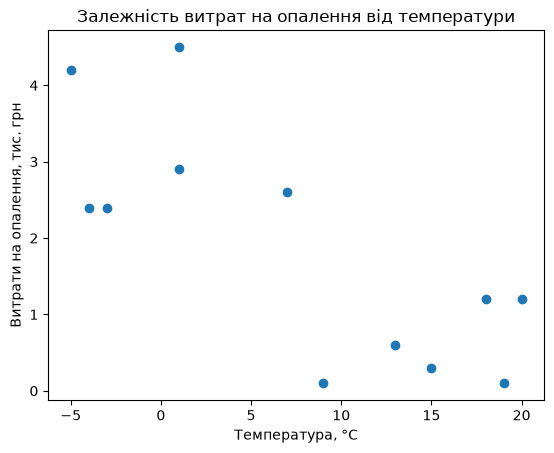


ЗАВДАННЯ 2
Пірсон: r = -0.772, p = 0.0032
Спірмен: rho = -0.694, p = 0.0123
95% ДІ для коефіцієнта Пірсона: [-0.933; -0.357]

КОРЕЛЯЦІЙНА МАТРИЦЯ ПІРСОНА


,температура,опалювальні_дні,витрати_на_опалення
температура,1.000000,-0.981129,-0.772482
опалювальні_дні,-0.981129,1.000000,0.777900
витрати_на_опалення,-0.772482,0.777900,1.000000



КОРЕЛЯЦІЙНА МАТРИЦЯ СПІРМЕНА


,температура,опалювальні_дні,витрати_на_опалення
температура,1.000000,-0.994729,-0.693666
опалювальні_дні,-0.994729,1.000000,0.712523
витрати_на_опалення,-0.693666,0.712523,1.000000



ЗАВДАННЯ 5
Пірсон після додавання викиду: r = -0.562, p = 0.0571
Спірмен після додавання викиду: rho = -0.718, p = 0.0085

Аномальний набір даних:


,місто,місяць,температура,опалювальні_дні,витрати_на_опалення
0,Чернігів,Січ,-5,23,21.0
1,Чернігів,Лют,-4,22,2.4
2,Чернігів,Бер,1,13,2.9
3,Чернігів,Кві,9,11,0.1
4,Чернігів,Тра,15,5,0.3
5,Чернігів,Чер,18,4,1.2
6,Чернігів,Лип,20,0,1.2
7,Чернігів,Сер,19,0,0.1
8,Чернігів,Вер,13,5,0.6
9,Чернігів,Жов,7,12,2.6


In [1]:
# Практика 16. Кореляційний аналіз
# Варіант 6 — Чернігів

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ============================================================
# ПОБУДОВА НАБОРУ ДАНИХ
# ============================================================

np.random.seed(6)

city = "Чернігів"
monthly_temp = [-5, -4, 1, 9, 15, 18, 20, 19, 13, 7, 1, -3]

months = ["Січ", "Лют", "Бер", "Кві", "Тра", "Чер",
          "Лип", "Сер", "Вер", "Жов", "Лис", "Гру"]

rows = []

for month, temp in zip(months, monthly_temp):
    heating_days = np.clip(
        18 - temp + np.random.normal(0, 1.5),
        0, 30
    )
    heating_days = round(heating_days)

    cost = 0.15 * heating_days + np.random.normal(0, 1.0)
    cost = round(max(cost, 0), 1)

    rows.append({
        "місто": city,
        "місяць": month,
        "температура": temp,
        "опалювальні_дні": heating_days,
        "витрати_на_опалення": cost
    })

climate = pd.DataFrame(rows)

print("НАБІР ДАНИХ")
display(climate)


# ============================================================
# ЗАВДАННЯ 1. ДІАГРАМА РОЗСІЮВАННЯ
# ============================================================

fig, ax = plt.subplots()

ax.scatter(
    climate["температура"],
    climate["витрати_на_опалення"]
)

ax.set_xlabel("Температура, °C")
ax.set_ylabel("Витрати на опалення, тис. грн")
ax.set_title("Залежність витрат на опалення від температури")

plt.show()

# Письмова відповідь:
# На діаграмі розсіювання спостерігається переважно негативний
# зв'язок між температурою та витратами на опалення.
# При підвищенні температури витрати загалом зменшуються.
# Хмара точок має приблизно лінійний характер, хоча через
# випадковий шум окремі точки відхиляються від загальної тенденції.
# Явних сильних викидів у початковому наборі немає.
# Такий напрямок зв'язку узгоджується з кодом генерації даних,
# оскільки кількість опалювальних днів розраховується на основі
# температури за формулою 18 - temp.


# ============================================================
# ЗАВДАННЯ 2. КОЕФІЦІЄНТИ ПІРСОНА І СПІРМЕНА
# ============================================================

pearson_result = pearsonr(
    climate["температура"],
    climate["витрати_на_опалення"]
)

spearman_result = spearmanr(
    climate["температура"],
    climate["витрати_на_опалення"]
)

print("\nЗАВДАННЯ 2")
print(
    f"Пірсон: r = {pearson_result.statistic:.3f}, "
    f"p = {pearson_result.pvalue:.4f}"
)

print(
    f"Спірмен: rho = {spearman_result.statistic:.3f}, "
    f"p = {spearman_result.pvalue:.4f}"
)

ci = pearson_result.confidence_interval(confidence_level=0.95)

print(
    f"95% ДІ для коефіцієнта Пірсона: "
    f"[{ci.low:.3f}; {ci.high:.3f}]"
)

# Письмова відповідь:
# Коефіцієнт Пірсона становить r = -0.772, а p-value = 0.0032.
# Оскільки p < 0.05, нульову гіпотезу про нульову кореляцію
# відхиляємо. Отже, між температурою та витратами на опалення
# існує статистично значущий негативний лінійний зв'язок.
#
# Коефіцієнт Спірмена становить rho = -0.694, а p-value = 0.0123.
# Оскільки p < 0.05, нульову гіпотезу також відхиляємо.
# Отже, ранговий зв'язок між змінними також є статистично
# значущим і негативним.
#
# Значення Пірсона і Спірмена мають однаковий напрямок і є
# досить близькими, хоча Пірсон за модулем більший.
# Це означає, що загальна тенденція є приблизно лінійною,
# але випадкові відхилення впливають на значення коефіцієнтів.
#
# 95%-й довірчий інтервал для коефіцієнта Пірсона становить
# [-0.933; -0.357]. За використаною моделлю побудови довірчого
# інтервалу істинне значення кореляції в генеральній сукупності
# оцінюється в цьому діапазоні з 95%-ю довірчою ймовірністю.
# Інтервал повністю знаходиться нижче нуля, що узгоджується
# з наявністю негативного зв'язку.


# ============================================================
# ЗАВДАННЯ 3. КОРЕЛЯЦІЙНА МАТРИЦЯ
# ============================================================

corr_data = climate[
    ["температура", "опалювальні_дні", "витрати_на_опалення"]
]

print("\nКОРЕЛЯЦІЙНА МАТРИЦЯ ПІРСОНА")
display(corr_data.corr())

print("\nКОРЕЛЯЦІЙНА МАТРИЦЯ СПІРМЕНА")
display(corr_data.corr(method="spearman"))

# Письмова відповідь:
# За коефіцієнтом Пірсона найсильніше корелюють температура
# та кількість опалювальних днів: r = -0.981.
# Найслабший зв'язок спостерігається між температурою
# та витратами на опалення: r = -0.772.
# Це очікуваний результат, оскільки кількість опалювальних
# днів безпосередньо розраховується з температури за формулою
# 18 - temp.
#
# За Спірменом висновок не змінюється.
# Найсильніший зв'язок також між температурою та опалювальними
# днями: rho = -0.995, а найслабший — між температурою
# та витратами: rho = -0.694.
# Отже, перехід від Пірсона до Спірмена не змінив загального
# висновку щодо сили та напрямку зв'язків.


# ============================================================
# ЗАВДАННЯ 4. КОРЕЛЯЦІЯ І ПРИЧИННІСТЬ
# ============================================================

# Письмова відповідь:
# Отримана негативна кореляція між температурою та витратами
# на опалення показує сильний зв'язок між цими змінними,
# але сама кореляція не є універсальним доказом причинності.
# У цьому наборі даних зв'язок є особливим, оскільки
# heating_days безпосередньо обчислюється з температури
# за формулою 18 - temp, а cost у свою чергу обчислюється
# з кількості опалювальних днів.
# Тому залежність у цьому випадку закладена безпосередньо
# в алгоритмі генерації даних, а не виникла лише через
# сторонній конфаундер.
# На відміну від прикладу «морозиво й утоплення», де спільною
# причиною може бути температура повітря, тут температура
# прямо використовується у формулах генерації пов'язаних змінних.


# ============================================================
# ЗАВДАННЯ 5. ПЕРЕВІРКА НА ВИКИД
# ============================================================

climate_anomaly = climate.copy()

# Аварія на котельні у січні — витрати зросли у 5 разів
climate_anomaly.loc[
    climate_anomaly["місяць"] == "Січ",
    "витрати_на_опалення"
] *= 5

pearson_anomaly = pearsonr(
    climate_anomaly["температура"],
    climate_anomaly["витрати_на_опалення"]
)

spearman_anomaly = spearmanr(
    climate_anomaly["температура"],
    climate_anomaly["витрати_на_опалення"]
)

print("\nЗАВДАННЯ 5")
print(
    f"Пірсон після додавання викиду: "
    f"r = {pearson_anomaly.statistic:.3f}, "
    f"p = {pearson_anomaly.pvalue:.4f}"
)

print(
    f"Спірмен після додавання викиду: "
    f"rho = {spearman_anomaly.statistic:.3f}, "
    f"p = {spearman_anomaly.pvalue:.4f}"
)

print("\nАномальний набір даних:")
display(climate_anomaly)

# Письмова відповідь:
# Після додавання аномального спостереження коефіцієнт Пірсона
# змінився з -0.772 до -0.562, тобто його абсолютне значення
# помітно зменшилося.
# Коефіцієнт Спірмена змінився значно слабше — з -0.694 до -0.718.
# Пірсон сильніше реагує на викид, оскільки використовує
# безпосередні числові значення та відхилення від середніх,
# тому дуже велике значення витрат суттєво впливає на результат.
# Спірмен працює з рангами, тому величина самого викиду має
# значно менший вплив на коефіцієнт.


# ============================================================
# КОНТРОЛЬНІ ПИТАННЯ
# ============================================================

# 1. Чому коефіцієнт Пірсона ділиться на добуток стандартних
# відхилень обох змінних і чому він знаходиться в [-1; 1]?
#
# Коефіцієнт Пірсона нормує коваріацію двох змінних на добуток
# їхніх стандартних відхилень. Завдяки цьому коефіцієнт не
# залежить від одиниць вимірювання змінних і показує силу
# та напрямок лінійного зв'язку. За нерівністю Коші — Шварца
# абсолютне значення нормованої коваріації не перевищує 1,
# тому коефіцієнт Пірсона завжди знаходиться в діапазоні [-1; 1].


# 2. Чому коефіцієнт Спірмена рахують на рангах?
#
# Спірмен спочатку замінює фактичні значення їхніми рангами,
# а потім оцінює зв'язок між цими рангами. Тому абсолютна
# величина значення має менший вплив на результат.
# Дуже великий викид змінює переважно його ранг, а не створює
# пропорційно величезного внеску, як у Пірсона.
# Через це Спірмен стійкіший до викидів і краще характеризує
# монотонний зв'язок.


# 3. Приклад ситуації, де r приблизно дорівнює 0, але зв'язок є.
#
# Прикладом може бути залежність y = x^2.
# Якщо значення x симетрично розподілені навколо нуля,
# то між x та x^2 може вийти кореляція Пірсона близька до нуля.
# При цьому залежність є сильною та чіткою, але вона нелінійна:
# зі збільшенням абсолютного значення x значення y збільшується.
# Пірсон вимірює саме лінійний зв'язок, тому не виявляє
# таку залежність належним чином.


# 4. Чому сильна кореляція не є доказом причинності?
#
# Кореляція показує статистичний зв'язок між змінними,
# але сама по собі не встановлює причинно-наслідковий механізм.
# Зв'язок може виникнути через третю змінну — конфаундер,
# або через зворотний причинний зв'язок.
# Тому для встановлення причинності потрібні додаткові дані,
# експеримент або обґрунтована причинна модель.
